In [131]:
from sklearn.metrics import accuracy_score, matthews_corrcoef, classification_report, f1_score
from sklearn.preprocessing import label_binarize, LabelEncoder
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

from model.visualization import plot_confusion_matrix

from pymmseqs.commands import createdb, search

# Homology-based Inference (HBI) baseline
### Non redundancy reduced train set. Test set is the same as from the normal model

In [132]:
train_all = pd.read_csv("train_all_df.csv")
test_set = pd.read_csv("../test_data.csv")

In [133]:
# assume best_all is your DataFrame
q_labels = set(train_all["Protein families"].unique())
t_labels = set(test_set["Protein families"].unique())

only_in_query  = q_labels  - t_labels
only_in_target = t_labels  - q_labels
both            = q_labels & t_labels
sym_diff        = q_labels ^ t_labels  # labels not in both

print("Only in train:")
print(only_in_query)
print("\nOnly in test:")
print(only_in_target)
print("\nIn both:")
print(both)
print("\nSymmetric difference (not in both):")
print(sym_diff)


Only in train:
{'AVIT (prokineticin) family', 'Venom protein 11 family', 'True venom lectin family', 'Ergtoxin family', 'NGF-beta family', 'Melittin family', 'Crotamine-myotoxin family'}

Only in test:
set()

In both:
{'Long chain scorpion toxin family', 'FARP (FMRFamide related peptide) family', 'Formicidae venom family', 'Conotoxin family', 'Peptidase S1 family', 'PDGF/VEGF growth factor family', 'CRISP family', 'Venom metalloproteinase (M12B) family', 'Natriuretic, Bradykinin potentiating peptide family', 'Neurotoxin family', 'Disintegrin family', 'Teretoxin family', 'Non-disulfide-bridged peptide (NDBP) superfamily', 'MCD family', 'Flavin monoamine oxidase family', 'Bradykinin-related peptide family', 'Three-finger toxin family', 'nontox', 'Insulin family', 'Venom Kunitz-type family', 'Snaclec family', 'Cationic peptide family', 'Long (3 C-C) scorpion toxin superfamily', 'other', 'Short scorpion toxin superfamily', 'Long (4 C-C) scorpion toxin superfamily', 'Limacoditoxin family', 

In [134]:
# Build a mapping of those rare labels → "other"
repl_map = {lbl: "other" for lbl in only_in_query}

# Apply to both columns (so your ground‐truth and preds share the same reduced label-space)
train_all["Protein families"]  = train_all["Protein families"].replace(repl_map)

# Sanity check: after this, the two label-sets should be identical
print(set(train_all["Protein families"].unique()) ^ set(test_set["Protein families"].unique()))

set()


In [180]:
train = createdb("train_all_members.fasta", "tmp/train_db")
test = createdb("../test_data.fasta", "tmp/test_db")


-------------------- Running a mmseqs2 command --------------------
✓ Detailed execution log has been saved
✓ Database creation completed successfully
  Results saved to: /Users/selin/PycharmProjects/ToxFam/benchmark/HBI/tmp/train_db

-------------------- Running a mmseqs2 command --------------------
✓ Detailed execution log has been saved
✓ Database creation completed successfully
  Results saved to: /Users/selin/PycharmProjects/ToxFam/benchmark/HBI/tmp/test_db


In [181]:
search_res = search(test.to_path(),
                    train.to_path(),
                    "tmp/search_res",
                    "tmp/tmp",
                    s=9,
                    e="inf",
                    min_seq_id=0.0,
                    max_seqs=100_000)


-------------------- Running a mmseqs2 command --------------------
✓ Detailed execution log has been saved
✓ Search completed successfully
  Results saved to: /Users/selin/PycharmProjects/ToxFam/benchmark/HBI/tmp/search_res


In [182]:
res = search_res.to_pandas()
res

Output is not readable. Executing convertalis command to convert the alignment database to a readable format.

-------------------- Running a mmseqs2 command --------------------
✓ Detailed execution log has been saved
✓ ConvertAlis completed successfully
  Results saved to: /Users/selin/PycharmProjects/ToxFam/benchmark/HBI/tmp/search_res.tsv


,query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits
0,P01502,P68407,0.908,26,2,0,1,26,23,48,4.769000e-10,52
1,P01502,P68408,0.908,26,2,0,1,26,23,48,4.769000e-10,52
2,P01502,P68409,0.908,26,2,0,1,26,23,48,4.769000e-10,52
3,P01502,P59261,0.908,26,2,0,1,26,23,48,4.769000e-10,52
4,P01502,P59262,0.908,26,2,0,1,26,23,48,4.769000e-10,52
...,...,...,...,...,...,...,...,...,...,...,...,...
139548365,Q24256,Q9D2Y9,0.482,10,5,0,260,269,105,114,3.232000e+06,12
139548366,Q24256,P07737,0.310,17,11,0,177,193,35,51,4.260000e+06,12
139548367,Q24256,P62962,0.385,12,7,0,56,67,56,67,5.614000e+06,12
139548368,Q24256,P62963,0.385,12,7,0,56,67,56,67,5.614000e+06,12


In [183]:
len(res["query"].unique()) # not all test set samples get a hit? --> nan hbi

8485

In [184]:
best_hits = (
    res
    .loc[res.groupby("query")["evalue"].idxmin()]
    .reset_index(drop=True)
)
best_hits

,query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits
0,A0A023W0V6,O43612,0.587,22,9,0,23,44,74,95,4.611000e-01,28
1,A0A023W0W9,A0A023W168,0.703,69,20,0,43,109,15,83,7.204000e-25,100
2,A0A059UI30,A9XE60,0.993,72,0,0,1,72,1,72,2.006000e-44,153
3,A0A075B6J1,A0A087WSX0,0.799,104,21,0,1,104,1,104,1.794000e-50,173
4,A0A075B6J2,P01706,0.670,99,32,0,1,99,1,99,2.986000e-37,134
...,...,...,...,...,...,...,...,...,...,...,...,...
8480,W5XCJ6,B4XSY9,0.920,131,10,0,1,131,3,133,2.581000e-78,254
8481,X1WHY6,Q9C0C7,0.564,1290,546,0,3,1292,4,1257,0.000000e+00,1387
8482,X2JAU8,Q86WN1,0.218,805,539,0,1,805,1,690,2.636000e-52,204
8483,X5I9Y2,D4HPD6,0.756,43,10,0,1,43,1,43,1.371000e-15,69


In [185]:
# prepare df with ground truth (query_label = test gt)
all_queries = test_set[["identifier", "Protein families"]].rename(columns={"identifier": "query","Protein families": "query_label"})
best_all = all_queries.merge(best_hits, on="query", how="left")[["query","target","evalue", "query_label"]]

# add target labels (target_label = HBI prediction)
train_labels = train_all[["identifier", "Protein families"]].rename(columns={"identifier": "target", "Protein families": "target_label"})
best_all = best_all.merge(train_labels, on="target", how="left")

best_all

,query,target,evalue,query_label,target_label
0,P01502,P68407,4.769000e-10,other,other
1,Q7ZT98,Q7T1K6,3.642000e-137,CRISP family,CRISP family
2,Q91055,O19010,1.407000e-77,CRISP family,nontox
3,A6MFK9,Q3SB03,3.736000e-125,CRISP family,CRISP family
4,P0CB14,Q9W7S2,1.028000e-168,Venom metalloproteinase (M12B) family,Venom metalloproteinase (M12B) family
...,...,...,...,...,...
8542,A0A7S8MVF3,P63019,2.190000e-10,Long (3 C-C) scorpion toxin superfamily,Long (4 C-C) scorpion toxin superfamily
8543,A0F0C2,A0A7S8MV32,2.930000e-15,Long (3 C-C) scorpion toxin superfamily,Long (3 C-C) scorpion toxin superfamily
8544,Q4LCT2,Q4LCT0,2.901000e-30,Long (3 C-C) scorpion toxin superfamily,Long (3 C-C) scorpion toxin superfamily
8545,Q9BLM0,Q9BLM2,2.514000e-32,Long (3 C-C) scorpion toxin superfamily,Long (3 C-C) scorpion toxin superfamily


In [186]:
# assume best_all is your DataFrame
q_labels = set(best_all["query_label"].unique())
t_labels = set(best_all["target_label"].unique())

only_in_query  = q_labels  - t_labels
only_in_target = t_labels  - q_labels
both            = q_labels & t_labels
sym_diff        = q_labels ^ t_labels  # labels not in both

print("Only in test ground truth:")
print(only_in_query)
print("\nOnly in hbi inference:")
print(only_in_target)
print("\nIn both:")
print(both)
print("\nSymmetric difference (not in both):")
print(sym_diff)


Only in test ground truth:
set()

Only in hbi inference:
{nan}

In both:
{'Long chain scorpion toxin family', 'FARP (FMRFamide related peptide) family', 'Formicidae venom family', 'Conotoxin family', 'Peptidase S1 family', 'PDGF/VEGF growth factor family', 'CRISP family', 'Venom metalloproteinase (M12B) family', 'Natriuretic, Bradykinin potentiating peptide family', 'Neurotoxin family', 'Disintegrin family', 'Teretoxin family', 'Non-disulfide-bridged peptide (NDBP) superfamily', 'MCD family', 'Flavin monoamine oxidase family', 'Bradykinin-related peptide family', 'Three-finger toxin family', 'nontox', 'Insulin family', 'Venom Kunitz-type family', 'Snaclec family', 'Cationic peptide family', 'Long (3 C-C) scorpion toxin superfamily', 'other', 'Short scorpion toxin superfamily', 'Long (4 C-C) scorpion toxin superfamily', 'Limacoditoxin family', 'Scoloptoxin family', 'Phospholipase family', 'Vasopressin/oxytocin family'}

Symmetric difference (not in both):
{nan}


In [187]:
# 0) make a copy so we don’t overwrite your original
df = best_all.copy()

# 1) replace NaN predictions with “no hit”
df["target_label"] = df["target_label"].fillna("no hit")

# 2) build your valid class list off the training set + “no hit”
train_classes = list(train_labels["target_label"].unique())
if "no hit" not in train_classes:
    train_classes.append("no hit")
class_list = train_classes      # order defines axes
cls2idx    = {cls: i for i, cls in enumerate(class_list)}

le = LabelEncoder()
le.fit(class_list)

# Now when you map:
y_true_enc = df["query_label"].map({c:i for i,c in enumerate(le.classes_)}).to_numpy()
y_pred_enc = df["target_label"].map({c:i for i,c in enumerate(le.classes_)}).to_numpy()

# 3) map both columns to ints
y_true_enc = df["query_label"].map(cls2idx).to_numpy()
y_pred_enc = df["target_label"].map(cls2idx).to_numpy()

# 4) compute metrics
accuracy = accuracy_score(y_true_enc, y_pred_enc)
mcc      = matthews_corrcoef(y_true_enc, y_pred_enc)

# micro‐MCC over flattened one‐hots
n_classes  = len(class_list)
y_true_bin = label_binarize(y_true_enc, classes=range(n_classes))
y_pred_bin = label_binarize(y_pred_enc, classes=range(n_classes))
micro_mcc  = matthews_corrcoef(y_true_bin.ravel(), y_pred_bin.ravel())

# per-class report (dict form)
report_dict = classification_report(
    y_true_enc,
    y_pred_enc,
    labels       = range(n_classes),
    target_names = class_list,
    output_dict  = True,
    zero_division=0
)

# 5) print metrics
print(f"Accuracy : {accuracy:.4f}")
print(f"MCC      : {mcc:.4f}")
print(f"Micro‐MCC: {micro_mcc:.4f}\n")
print("Per-class metrics:\n")
print(classification_report(
    y_true_enc,
    y_pred_enc,
    labels       = range(n_classes),
    target_names = class_list,
    zero_division=0
))

plot_confusion_matrix(
  all_labels=y_true_enc,
  all_preds=y_pred_enc,
  label_encoder=le,
  output_path="confusion_matrix.png")

# ——— drop-in: save to JSON ———


numeric_metrics = {
    "Test_Accuracy": accuracy,
    "Test_MCC": mcc,
    "Test_Micro_MCC": micro_mcc
}

output = {
    "numeric_metrics": numeric_metrics,
    "classification_report": report_dict
}

out_path = Path("test_metrics.json")
out_path.write_text(json.dumps(output, indent=4))
print(f"Saved metrics JSON to {out_path}")


Accuracy : 0.9822
MCC      : 0.8394
Micro‐MCC: 0.9816

Per-class metrics:

                                                     precision    recall  f1-score   support

              Venom metalloproteinase (M12B) family       0.88      0.83      0.86        18
                                     Insulin family       1.00      1.00      1.00         2
                                 Scoloptoxin family       1.00      0.78      0.88        18
                                Peptidase S1 family       0.93      1.00      0.96        13
                               Phospholipase family       0.81      0.65      0.72        26
                           Venom Kunitz-type family       0.36      0.57      0.44         7
                                              other       0.85      0.69      0.76        32
                    Flavin monoamine oxidase family       0.67      1.00      0.80         2
                                   Conotoxin family       0.98      0.91      0.94     

In [195]:
df["target_label"].value_counts()

target_label
nontox                                                 8038
Conotoxin family                                        105
Neurotoxin family                                        65
no hit                                                   62
Three-finger toxin family                                37
Long (4 C-C) scorpion toxin superfamily                  30
other                                                    26
Short scorpion toxin superfamily                         25
Phospholipase family                                     21
Venom metalloproteinase (M12B) family                    17
Snaclec family                                           16
Scoloptoxin family                                       14
Peptidase S1 family                                      14
MCD family                                               11
Venom Kunitz-type family                                 11
Natriuretic, Bradykinin potentiating peptide family       7
Formicidae venom family    

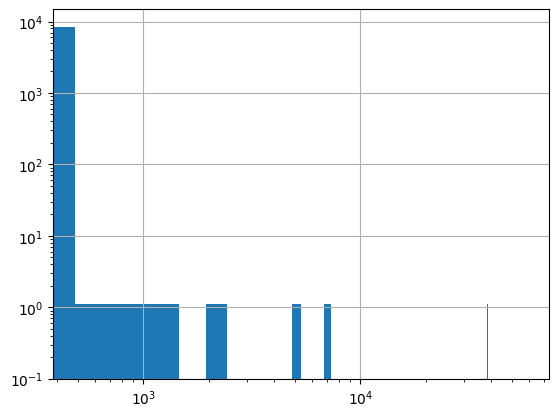

In [196]:
#df["evalue"].hist(logx=True)

fig, ax = plt.subplots()
df["evalue"].hist(ax=ax, bins=120, bottom=0.1)
ax.set_yscale('log')
ax.set_xscale('log')

### comparison

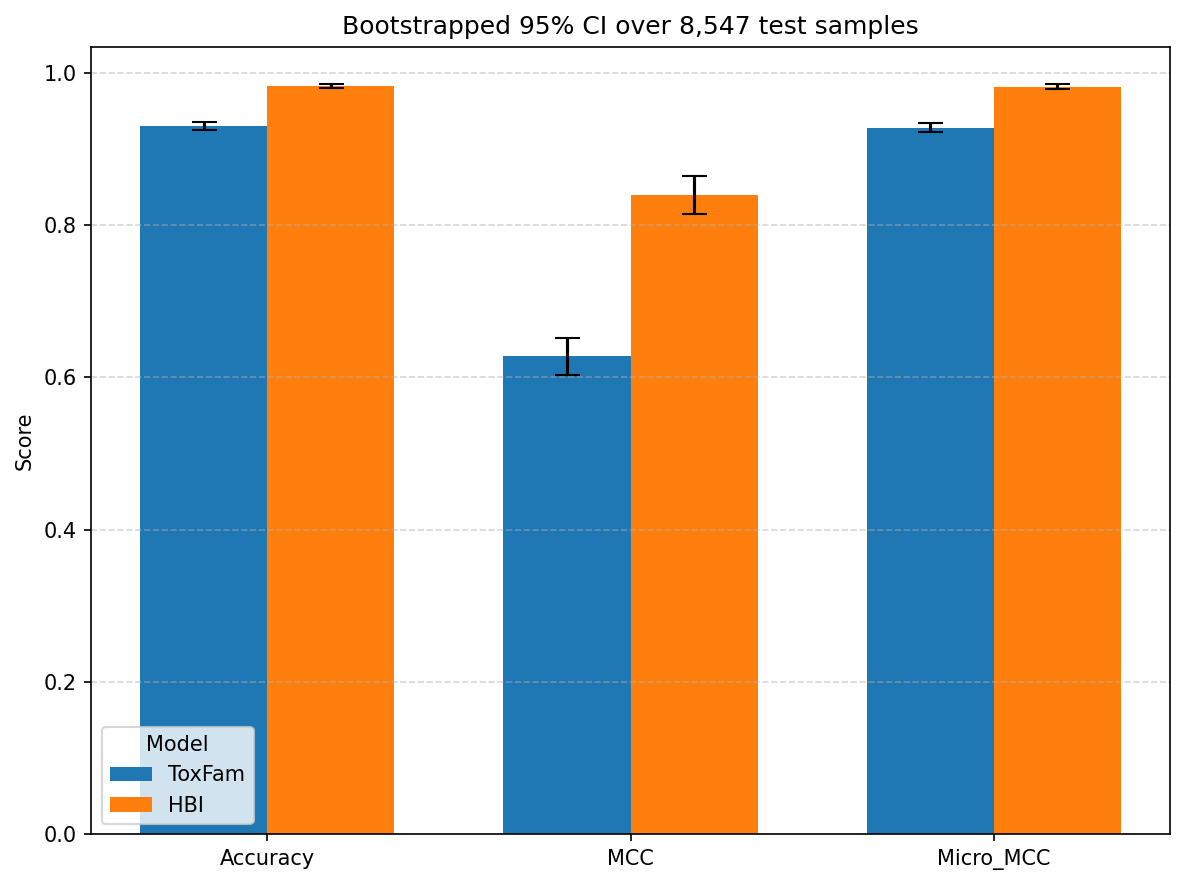

In [189]:
# HBI
hbi = best_all.copy()
hbi["target_label"] = hbi["target_label"].fillna("no hit")
hbi_true = hbi["query_label"].values
hbi_pred = hbi["target_label"].values

# ToxFam
tox = pd.read_csv("../../model/model_output/test_predictions.csv")
#tox["prediction"]     = tox["prediction"].fillna("no hit")
tox_true = tox["actual_label"].values
tox_pred = tox["prediction"].values

# ─────────── 2) Encode labels to integers (shared universe) ───────────
all_classes = sorted(set(hbi_true) | set(hbi_pred) | set(tox_true) | set(tox_pred))
cls2idx = {c:i for i,c in enumerate(all_classes)}

y_true_hbi  = np.array([cls2idx[c] for c in hbi_true])
y_pred_hbi  = np.array([cls2idx[c] for c in hbi_pred])
y_true_tox  = np.array([cls2idx[c] for c in tox_true])
y_pred_tox  = np.array([cls2idx[c] for c in tox_pred])

# ─────────── 3) Bootstrap function ───────────
def bootstrap_metrics(y_true, y_pred, n_bootstrap=1000, ci=0.95, seed=0):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    accs, mccs, mmccs = [], [], []
    classes = np.arange(len(all_classes))
    for _ in range(n_bootstrap):
        idx = rng.choice(n, n, True)
        yt, yp = y_true[idx], y_pred[idx]
        accs.append(accuracy_score(yt, yp))
        mccs.append(matthews_corrcoef(yt, yp))
        # micro‐MCC on flattened one‐hots
        ytb = label_binarize(yt, classes=classes).ravel()
        ypb = label_binarize(yp, classes=classes).ravel()
        mmccs.append(matthews_corrcoef(ytb, ypb))
    def ci_stats(arr):
        lo, hi = np.percentile(arr, [(1-ci)/2*100, (1+ci)/2*100])
        return np.mean(arr), lo, hi
    return {
        "Accuracy":   ci_stats(accs),
        "MCC":        ci_stats(mccs),
        "Micro_MCC":  ci_stats(mmccs),
    }

# ─────────── 4) Run bootstraps ───────────
res_hbi = bootstrap_metrics(y_true_hbi, y_pred_hbi)
res_tox = bootstrap_metrics(y_true_tox, y_pred_tox)

# ─────────── 5) Prepare for plotting ───────────
models  = ["ToxFam", "HBI"]
metrics = ["Accuracy", "MCC", "Micro_MCC"]

# means shape: (n_models, n_metrics)
means = np.array([
    [res_tox[m][0],  res_hbi[m][0]]
    for m in metrics
]).T

# yerr shape: (2, n_models, n_metrics)
low  = np.array([[res_tox[m][0]-res_tox[m][1],  res_hbi[m][0]-res_hbi[m][1]] for m in metrics]).T
high = np.array([[res_tox[m][2]-res_tox[m][0],  res_hbi[m][2]-res_hbi[m][0]] for m in metrics]).T
yerr = np.stack([low, high])

# ─────────── 6) Plot ───────────
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
for i, mdl in enumerate(models):
    ax.bar(
        x + i*width,
        means[i],
        width=width,
        yerr=yerr[:, i],
        capsize=6,
        label=mdl
    )

offset = width*(len(models)-1)/2
ax.set_xticks(x + offset)
ax.set_xticklabels(metrics, ha="center")

ax.set_ylabel("Score")
ax.set_title("Bootstrapped 95% CI over 8,547 test samples")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(title="Model")
plt.tight_layout()
plt.savefig("plots/overall_comparison.png")
plt.show()


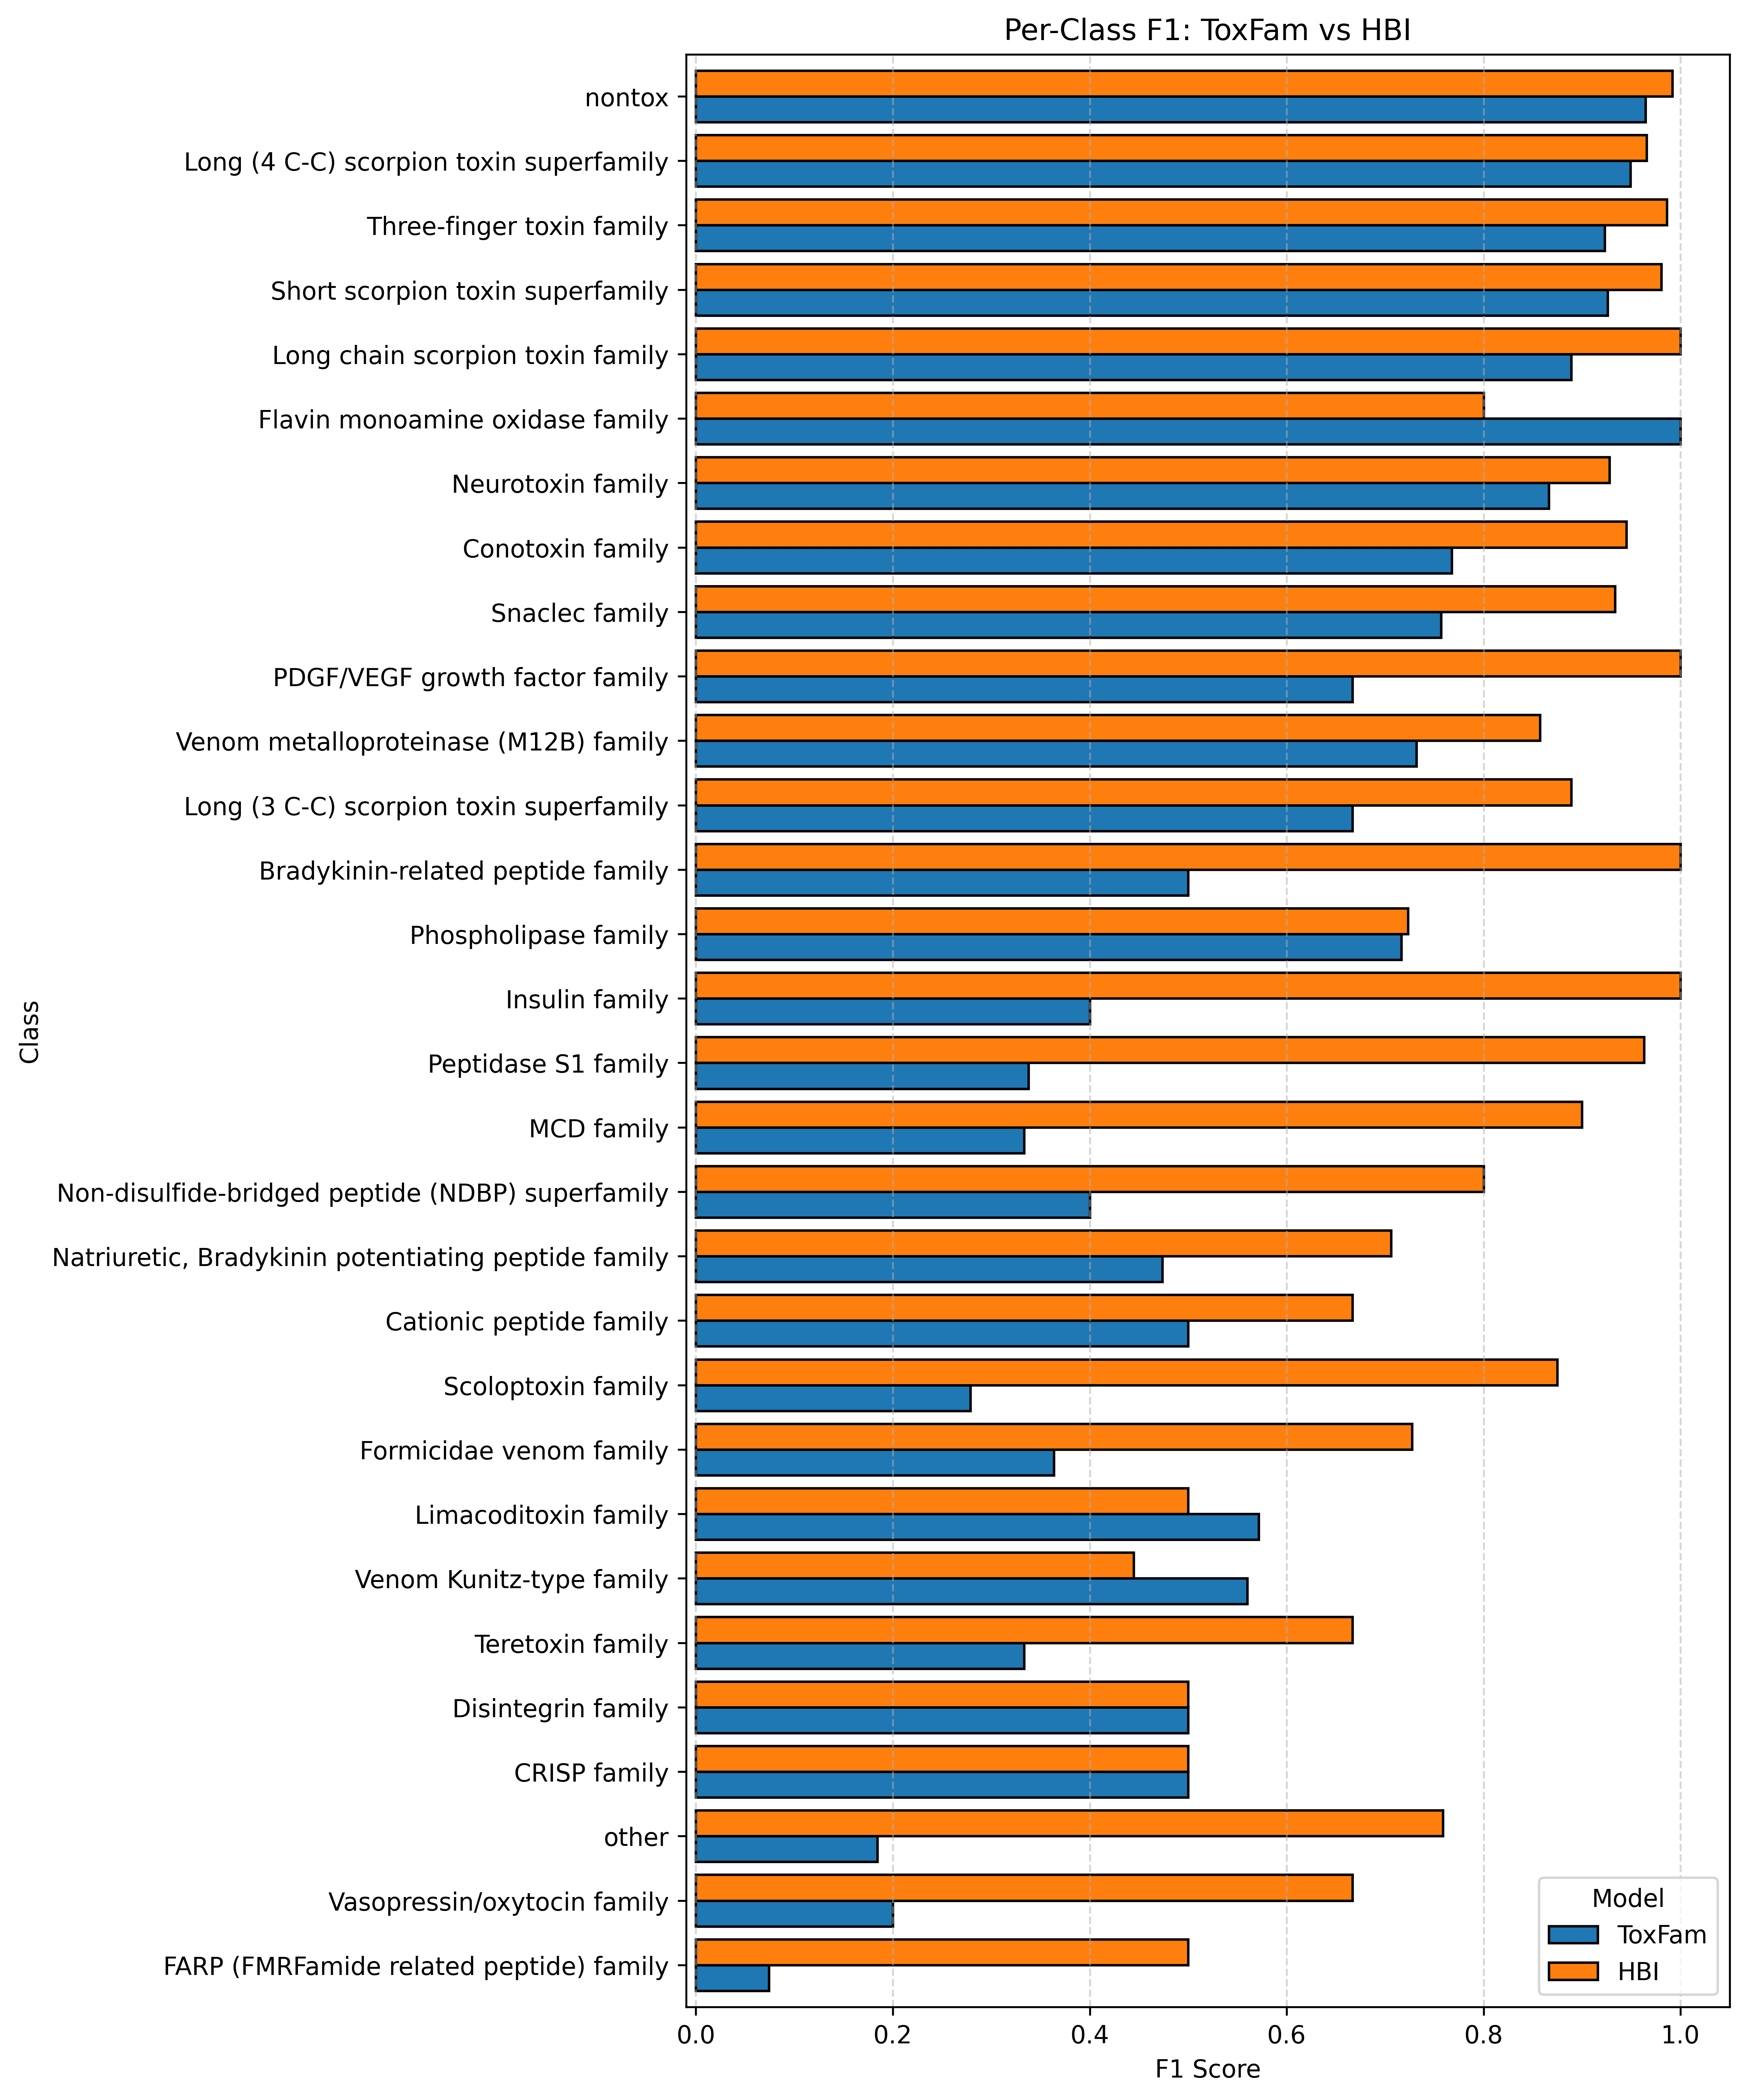

In [190]:
# ——— 1) Load your two sets of predictions ———
hbi = best_all.copy()
hbi["target_label"] = hbi["target_label"].fillna("no hit")
hbi_true = hbi["query_label"].values
hbi_pred = hbi["target_label"].values

tox = pd.read_csv("../../model/model_output/test_predictions.csv")
tox_true = tox["actual_label"].values
tox_pred = tox["prediction"].values

# ——— 2) Compute classification reports ———
cls_report_hbi = classification_report(hbi_true, hbi_pred, output_dict=True, zero_division=0)
cls_report_tox = classification_report(tox_true, tox_pred, output_dict=True, zero_division=0)

# ——— 3) Extract only the per-class entries ———
hbi_per = {k: v for k, v in cls_report_hbi.items() if isinstance(v, dict)}
tox_per = {k: v for k, v in cls_report_tox.items() if isinstance(v, dict)}

# ——— 4) Build the union of all classes, then remove "no hit" ———
all_classes = sorted((set(hbi_per) | set(tox_per)) - {"no hit", "macro avg", "weighted avg"})

# ——— 5) Turn into DataFrames reindexed to that filtered set ———
hbi_df = pd.DataFrame.from_dict(hbi_per, orient="index").reindex(all_classes, fill_value=0)
tox_df = pd.DataFrame.from_dict(tox_per, orient="index").reindex(all_classes, fill_value=0)

# ——— 6) Assemble F1-scores side by side ———
f1_df = pd.DataFrame({
    "ToxFam": tox_df["f1-score"],
    "HBI"   : hbi_df["f1-score"]
}, index=all_classes)

# (Optional) sort by average F1 so lowest-performing classes are on top
f1_df["avg"] = f1_df.mean(axis=1)
f1_df = f1_df.sort_values("avg").drop(columns="avg")

# ——— 7) Plot horizontal grouped bars with custom figure & axes ———
bar_height = 0.4
total_height = max(6, bar_height * len(f1_df))

fig, ax = plt.subplots(figsize=(10, total_height), dpi=480)
f1_df.plot.barh(ax=ax, width=0.8, edgecolor="black", capsize=3)

ax.set_xlabel("F1 Score")
ax.set_ylabel("Class")
ax.set_xlim(-0.01, 1.05)
ax.set_title("Per-Class F1: ToxFam vs HBI")
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.legend(title="Model")

plt.tight_layout()
plt.savefig("plots/f1_class_comparison.png")
plt.show()

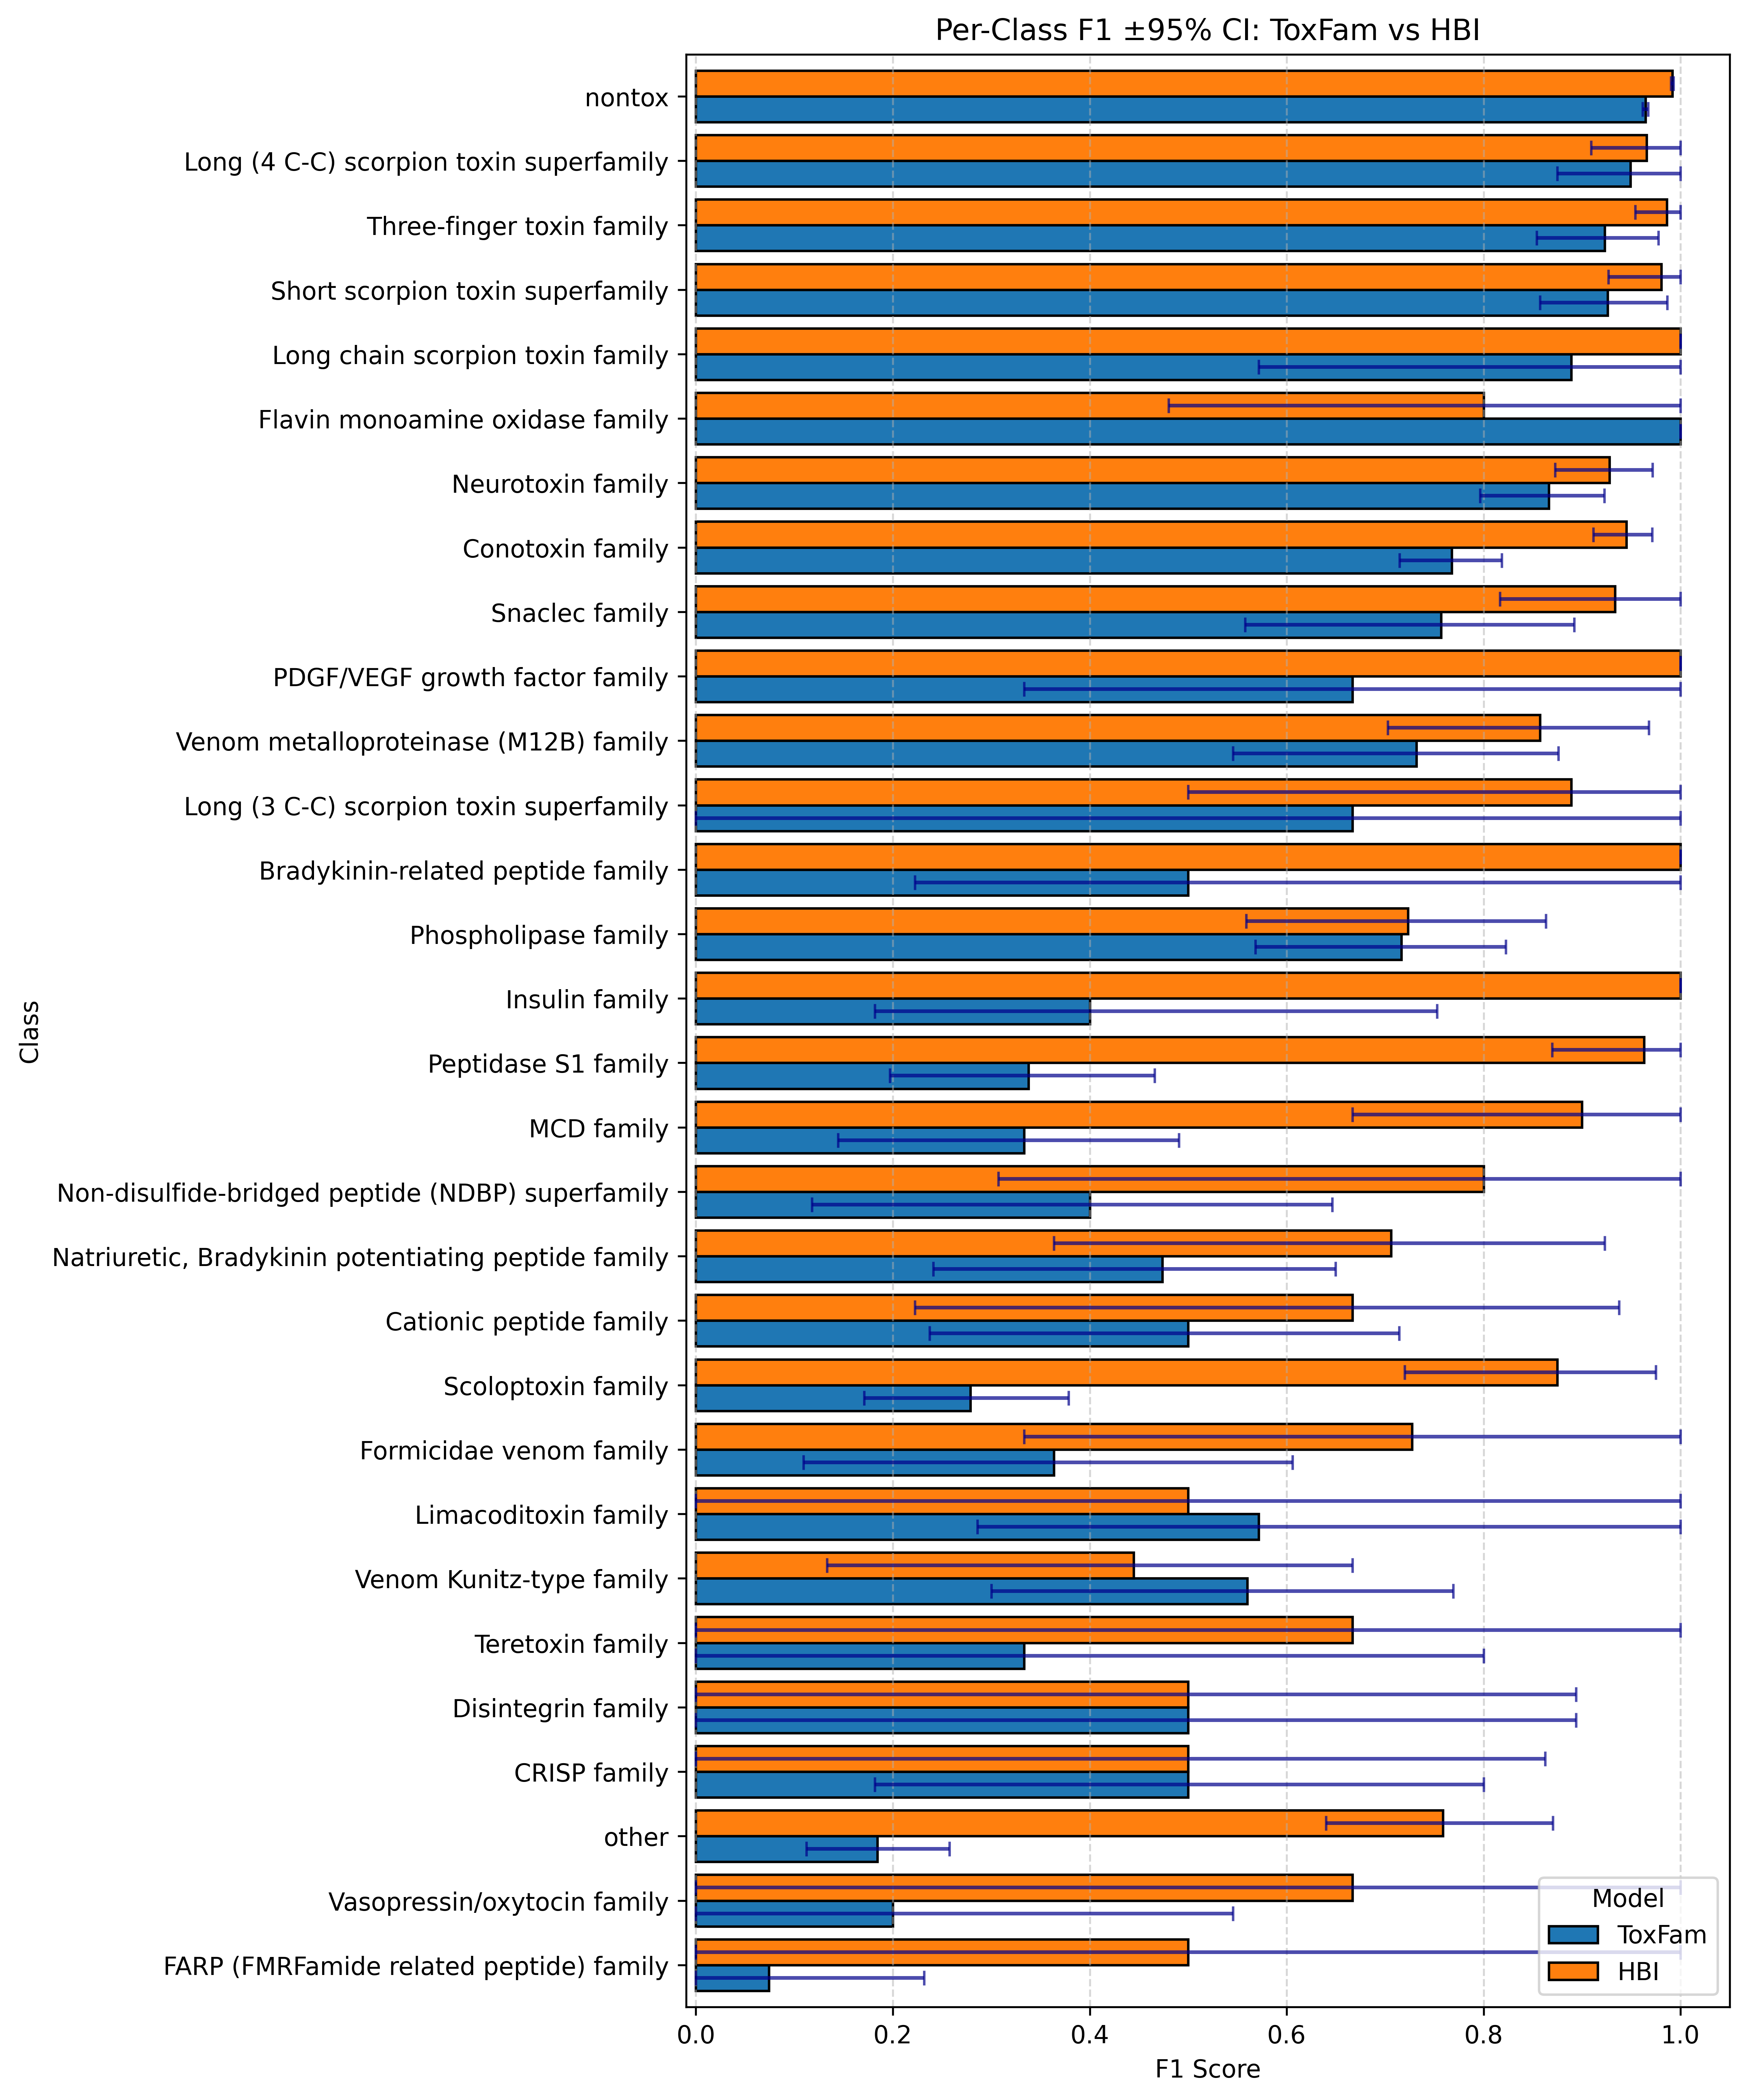

In [191]:
# ——— 1) Load your two sets of predictions ———
hbi = best_all.copy()
hbi["target_label"] = hbi["target_label"].fillna("no hit")
hbi_true = hbi["query_label"].values
hbi_pred = hbi["target_label"].values

tox = pd.read_csv("../../model/model_output/test_predictions.csv")
tox_true = tox["actual_label"].values
tox_pred = tox["prediction"].values

# ——— 2) Compute classification reports ———
cls_report_hbi = classification_report(hbi_true, hbi_pred, output_dict=True, zero_division=0)
cls_report_tox = classification_report(tox_true, tox_pred, output_dict=True, zero_division=0)

# ——— 3) Extract per-class entries ———
hbi_per = {k: v for k, v in cls_report_hbi.items() if isinstance(v, dict)}
tox_per = {k: v for k, v in cls_report_tox.items() if isinstance(v, dict)}

# ——— 4) Union of classes minus unwanted ———
all_classes = sorted(set(hbi_per) | set(tox_per))
all_classes = [c for c in all_classes if c not in {"no hit", "macro avg", "weighted avg"}]

# ——— 5) Build dataframes ———
hbi_df = pd.DataFrame.from_dict(hbi_per, orient="index").reindex(all_classes, fill_value=0)
tox_df = pd.DataFrame.from_dict(tox_per, orient="index").reindex(all_classes, fill_value=0)

# ——— 6) Exact F1 centers & sort ———
f1_df = pd.DataFrame({
    "ToxFam": tox_df["f1-score"],
    "HBI"   : hbi_df["f1-score"]
}, index=all_classes)
f1_df["avg"] = f1_df.mean(axis=1)
f1_df = f1_df.sort_values("avg").drop(columns="avg")

# ——— 7) Bootstrap function ———
def bootstrap_per_class_f1(y_true, y_pred, classes, n_bootstrap=1000, ci=0.95, seed=0):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    boot = {c: [] for c in classes}
    for _ in range(n_bootstrap):
        idx = rng.choice(n, n, True)
        yt, yp = y_true[idx], y_pred[idx]
        for c in classes:
            class_present = sum(yt == c)
            if class_present:
                boot[c].append(f1_score(yt == c, yp == c))
    lo_pct, hi_pct = (1 - ci)/2 * 100, (1 + ci)/2 * 100
    stats = {}
    for c, vals in boot.items():
        lo, hi = np.percentile(vals, [lo_pct, hi_pct])
        # clamp lo & hi to [0,1]
        lo = max(lo, 0.0)
        hi = min(hi, 1.0)
        stats[c] = (lo, hi)
    return stats

classes    = list(f1_df.index)
hbi_stats  = bootstrap_per_class_f1(hbi_true, hbi_pred, classes, n_bootstrap=500, seed=42)
tox_stats  = bootstrap_per_class_f1(tox_true, tox_pred, classes, n_bootstrap=500, seed=42)

# ——— 8) Build centers + explicit lower/upper errors ———
# exact centers
centers = {
    "ToxFam": f1_df["ToxFam"].values,
    "HBI"   : f1_df["HBI"].values
}

# raw percentiles
tox_lo = np.array([tox_stats[c][0] for c in classes])
tox_hi = np.array([tox_stats[c][1] for c in classes])
hbi_lo = np.array([hbi_stats[c][0] for c in classes])
hbi_hi = np.array([hbi_stats[c][1] for c in classes])

# distances to mean
tox_lower = centers["ToxFam"] - tox_lo
tox_upper = tox_hi - centers["ToxFam"]
hbi_lower = centers["HBI"]    - hbi_lo
hbi_upper = hbi_hi    - centers["HBI"]

# clamp distances so mean - lower ≥0 and mean + upper ≤1
tox_lower = np.minimum(tox_lower, centers["ToxFam"])
tox_upper = np.minimum(tox_upper, 1 - centers["ToxFam"])
hbi_lower = np.minimum(hbi_lower, centers["HBI"])
hbi_upper = np.minimum(hbi_upper, 1 - centers["HBI"])

# ensure non-negative
tox_lower = np.clip(tox_lower, 0, None)
tox_upper = np.clip(tox_upper, 0, None)
hbi_lower = np.clip(hbi_lower, 0, None)
hbi_upper = np.clip(hbi_upper, 0, None)

errors = {
    "ToxFam": (tox_lower, tox_upper),
    "HBI"   : (hbi_lower, hbi_upper)
}

# ——— 9) Prepare error array of shape (n_series, 2, n_points) ———
# Series order must match the columns in f1_df: ["ToxFam", "HBI"]
n = len(classes)
err = np.empty((2, 2, n))
# for series 0 (ToxFam):
err[0, 0, :] = tox_lower   # lower errors
err[0, 1, :] = tox_upper   # upper errors
# for series 1 (HBI):
err[1, 0, :] = hbi_lower
err[1, 1, :] = hbi_upper

# ——— 10) Plot with pandas’ barh exactly as before, just adding xerr=err ———
bar_height = 0.4
total_height = max(6, bar_height * n)

fig, ax = plt.subplots(figsize=(10, total_height), dpi=480)
f1_df.plot.barh(
    ax=ax,
    width=0.8,
    edgecolor="black",
    capsize=3,
    xerr=err,
    error_kw={"alpha": 0.7, "ecolor": "darkblue"}
)

ax.set_xlabel("F1 Score")
ax.set_ylabel("Class")
ax.set_xlim(-0.01, 1.05)
ax.set_title("Per-Class F1 ±95% CI: ToxFam vs HBI")
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.legend(title="Model")

plt.tight_layout()
plt.savefig("plots/f1_class_comparison_errors.png")
plt.show()



/var/folders/6k/gr_1_h_97154rq71pm_q3jn40000gn/T/ipykernel_52044/1072020721.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('rainbow', len(classes))


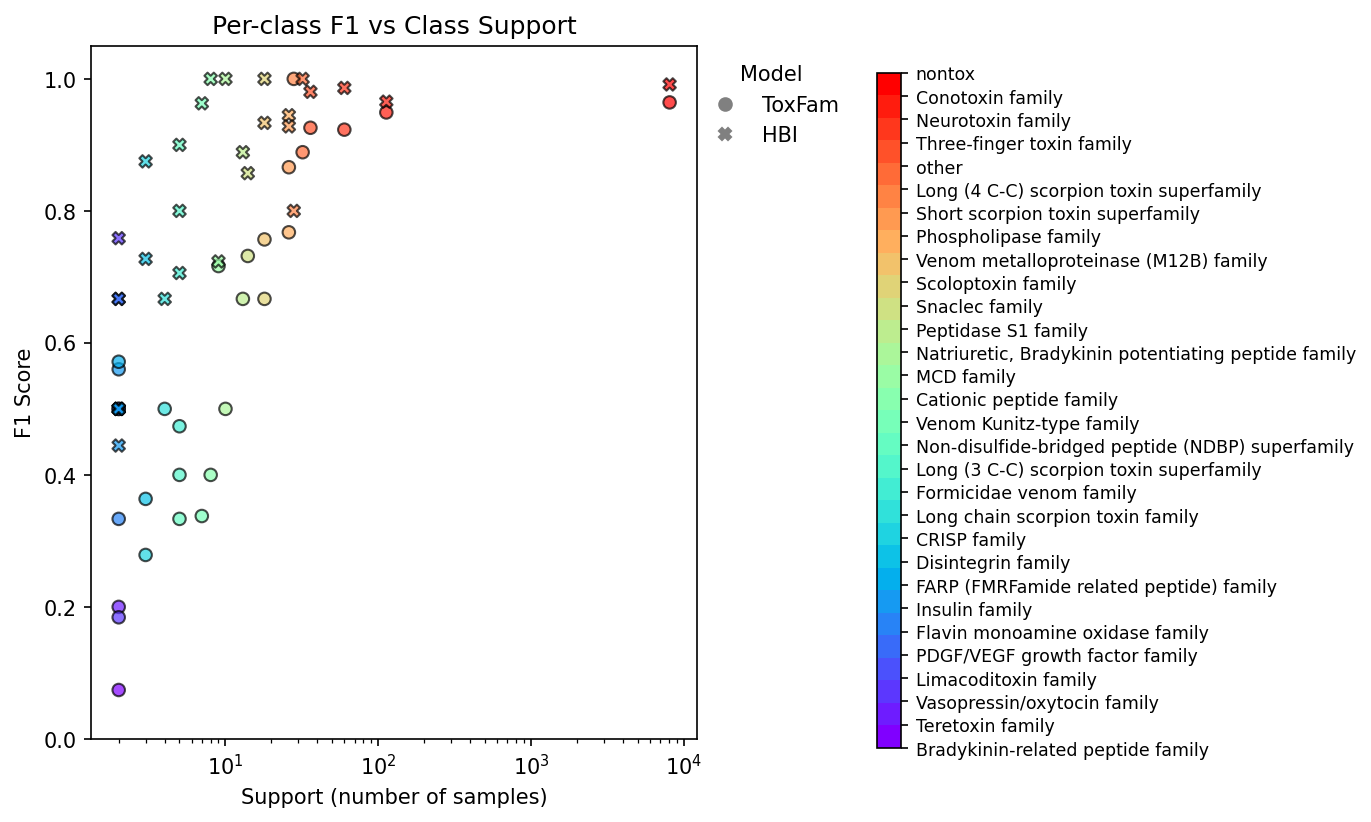

In [192]:
classes   = support_sorted.index
supports  = support_sorted.values
class_idx = np.arange(len(classes))

cmap = plt.cm.get_cmap('rainbow', len(classes))
norm = mcolors.Normalize(vmin=0, vmax=len(classes)-1)

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

# leave plenty of room on right
plt.subplots_adjust(right=0.63)

# scatter
sc_tox = ax.scatter(
    supports, f1_df['ToxFam'],
    c=class_idx, cmap=cmap, norm=norm,
    marker='o', edgecolor='black', alpha=0.7
)
sc_hbi = ax.scatter(
    supports, f1_df['HBI'],
    c=class_idx, cmap=cmap, norm=norm,
    marker='X', edgecolor='black', alpha=0.7
)

# axes labels
ax.set_xscale('log')
ax.set_xlabel("Support (number of samples)")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.05)
ax.set_title("Per-class F1 vs Class Support")

# Model‐shape legend (moved left)
model_handles = [
    Line2D([], [], marker='o', color='gray', linestyle='', label='ToxFam'),
    Line2D([], [], marker='X', color='gray', linestyle='', label='HBI'),
]
fig.legend(
    handles=model_handles,
    title="Model",
    loc="upper left",
    bbox_to_anchor=(0.62, 0.88),  # 62% from left, 85% from bottom
    frameon=False
)

# Colorbar in its own Axes (moved right)
cax = fig.add_axes([0.78, 0.10, 0.02, 0.75])  # left=78%, bottom=10%, width=2%, height=75%
cb = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cax
)
cb.set_ticks(class_idx)
cb.set_ticklabels(classes)
cb.ax.tick_params(labelsize='small')
plt.savefig("plots/f1_class_comparison_scatter.png")
plt.show()
